In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
sns.set_style('whitegrid')
sns.set_palette("Set2")

# Leer los datos

In [3]:
df_fe = pd.read_csv("../../../data/respuestas_fede.csv")
print("Shape of data: ", df_fe.shape)

#globales
marmol = df_fe.loc[df_fe["escuela"] == "Colegio Modelo Mármol"]
mantovani = df_fe.loc[df_fe["escuela"] == "Escuela Nueva Juan Mantovani"]
fig_name_prefix = 'acceso_fotos'
file_ext = '.png'
dpi_value = 200
include_title = True

Shape of data:  (369, 22)


# ¿Quién tiene acceso a las fotos que tengo guardadas en mi celular?

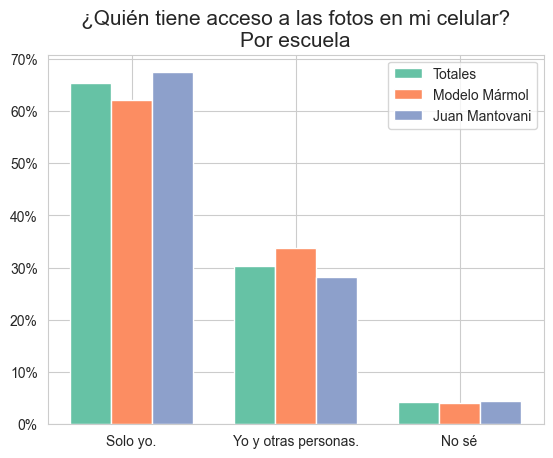

In [4]:
# Quien tiene acceso a las fotos en mi celular
data_total = df_fe["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"})

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("¿Quién tiene acceso a las fotos en mi celular?\nPor escuela", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()

plt.savefig(fig_name_prefix + '_por_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* Solo yo es un 5% más elegida en el Mantovani.
* Yo y otras personas un 5% más en el Mármol.

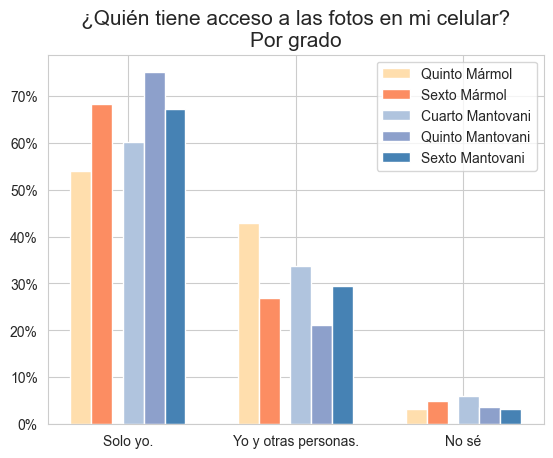

In [5]:
# Quien tiene acceso a las fotos en mi celular - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Marmol',
                                1:'Sexto Marmol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'})

bar_width = 0.25

br1 = [1, 3, 5]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Marmol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Marmol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("¿Quién tiene acceso a las fotos en mi celular?\nPor grado", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')

plt.savefig(fig_name_prefix + '_por_grado_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

* Mármol: Solo yo un 15% más seleccionado de 5to a 6to. Yo y otras peronas un 15% menos seleccionado de 5to a 6to.
* Mantovani: Las variaciones son iguales pero en menor porcentaje para el Mantovani. Aumentan solo yo al crecer y cecrementan yo y otras personas.

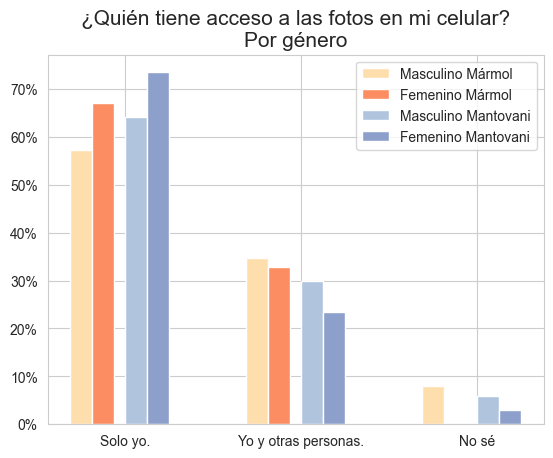

In [6]:
# Quien tiene acceso a las fotos en mi celular - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Marmol", 1: "Femenino Marmol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"})

bar_width = 0.25

br1 = [1, 3, 5]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Marmol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Marmol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
if include_title:
       plt.title("¿Quién tiene acceso a las fotos en mi celular?\nPor género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')

plt.savefig(fig_name_prefix + '_por_genero_y_escuela' + file_ext, bbox_inches='tight', dpi=dpi_value)

En ambos colegios Solo yo es un 10% más elegido por las chicas y yo y otras peronas es un 5% menos elegido por las chicas

# Análisis estadístico

In [7]:
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import chi2_contingency

def mostrar_intervalos_confianza(series, alpha=0.05):
    """Calcula intervalos de confianza de la proporción (Wilson) para cada categoría."""
    n = len(series)
    counts = series.value_counts()
    rows = []
    for cat in counts.index:
        count = counts[cat]
        prop = count / n
        ci_low, ci_high = proportion_confint(count, n, alpha=alpha, method='wilson')
        rows.append({
            'Respuesta': cat,
            'n': count,
            'Proporción': f'{prop:.1%}',
            'IC 95% inferior': f'{ci_low:.1%}',
            'IC 95% superior': f'{ci_high:.1%}',
            'Margen de error': f'±{(ci_high - ci_low)/2:.1%}'
        })
    return pd.DataFrame(rows)

def test_chi2_y_cramers_v(df, col_grupo, col_respuesta, nombre_comparacion):
    """Realiza test de chi-cuadrado y calcula Cramér's V entre dos o más grupos."""
    contingency = pd.crosstab(df[col_grupo], df[col_respuesta])
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.sum().sum()
    k = min(contingency.shape)
    v = np.sqrt(chi2 / (n * (k - 1)))

    print(f"\n{'='*60}")
    print(f"Test Chi-cuadrado: {nombre_comparacion}")
    print(f"{'='*60}")
    print(f"\nTabla de contingencia:")
    display(contingency)
    print(f"\nχ² = {chi2:.4f},  p-valor = {p:.4f},  gl = {dof}")
    print(f"Cramér's V = {v:.4f}")

    if p < 0.05:
        print(f"\n✓ La diferencia ES estadísticamente significativa (p < 0.05)")
    else:
        print(f"\n✗ La diferencia NO es estadísticamente significativa (p ≥ 0.05)")

    if v < 0.1:
        efecto = "despreciable (V < 0.1)"
    elif v < 0.3:
        efecto = "pequeño (0.1 ≤ V < 0.3)"
    elif v < 0.5:
        efecto = "mediano (0.3 ≤ V < 0.5)"
    else:
        efecto = "grande (V ≥ 0.5)"
    print(f"Tamaño del efecto: {efecto}")

    return chi2, p, v

## Intervalos de confianza y test de chi-cuadrado: por escuela

In [8]:
col = "quien_acceso_celular"

print("INTERVALOS DE CONFIANZA (95%) - Por escuela")
print("="*60)

for nombre, datos in [("Total", df_fe), ("Colegio Modelo Mármol", marmol), ("Escuela Nueva Juan Mantovani", mantovani)]:
    print(f"\n--- {nombre} (n={len(datos)}) ---")
    display(mostrar_intervalos_confianza(datos[col]))

# Test Chi-cuadrado: Mármol vs Mantovani
test_chi2_y_cramers_v(df_fe, "escuela", col, "Mármol vs Mantovani");

INTERVALOS DE CONFIANZA (95%) - Por escuela

--- Total (n=369) ---


,Respuesta,n,Proporción,IC 95% inferior,IC 95% superior,Margen de error
0,Solo yo.,241,65.3%,60.3%,70.0%,±4.8%
1,Yo y otras personas.,112,30.4%,25.9%,35.2%,±4.7%
2,No sé,16,4.3%,2.7%,6.9%,±2.1%



--- Colegio Modelo Mármol (n=145) ---


,Respuesta,n,Proporción,IC 95% inferior,IC 95% superior,Margen de error
0,Solo yo.,90,62.1%,54.0%,69.6%,±7.8%
1,Yo y otras personas.,49,33.8%,26.6%,41.8%,±7.6%
2,No sé,6,4.1%,1.9%,8.7%,±3.4%



--- Escuela Nueva Juan Mantovani (n=224) ---


,Respuesta,n,Proporción,IC 95% inferior,IC 95% superior,Margen de error
0,Solo yo.,151,67.4%,61.0%,73.2%,±6.1%
1,Yo y otras personas.,63,28.1%,22.6%,34.3%,±5.8%
2,No sé,10,4.5%,2.4%,8.0%,±2.8%



Test Chi-cuadrado: Mármol vs Mantovani

Tabla de contingencia:


quien_acceso_celular,No sé,Solo yo.,Yo y otras personas.
escuela,,,
Colegio Modelo Mármol,6,90,49
Escuela Nueva Juan Mantovani,10,151,63



χ² = 1.3379,  p-valor = 0.5123,  gl = 2
Cramér's V = 0.0602

✗ La diferencia NO es estadísticamente significativa (p ≥ 0.05)
Tamaño del efecto: despreciable (V < 0.1)


## Intervalos de confianza y test de chi-cuadrado: por grado

In [9]:
col = "quien_acceso_celular"

print("INTERVALOS DE CONFIANZA (95%) - Por grado y escuela")
print("="*60)

for escuela_nombre, escuela_df in [("Mármol", marmol), ("Mantovani", mantovani)]:
    for grado in sorted(escuela_df['grado'].unique()):
        subset = escuela_df[escuela_df['grado'] == grado]
        print(f"\n--- {grado} {escuela_nombre} (n={len(subset)}) ---")
        display(mostrar_intervalos_confianza(subset[col]))

# Test Chi-cuadrado por grado dentro de cada escuela
test_chi2_y_cramers_v(marmol, "grado", col, "Quinto vs Sexto (Mármol)")
test_chi2_y_cramers_v(mantovani, "grado", col, "Cuarto vs Quinto vs Sexto (Mantovani)");

INTERVALOS DE CONFIANZA (95%) - Por grado y escuela

--- Quinto Mármol (n=63) ---


,Respuesta,n,Proporción,IC 95% inferior,IC 95% superior,Margen de error
0,Solo yo.,34,54.0%,41.8%,65.7%,±12.0%
1,Yo y otras personas.,27,42.9%,31.4%,55.1%,±11.9%
2,No sé,2,3.2%,0.9%,10.9%,±5.0%



--- Sexto Mármol (n=82) ---


,Respuesta,n,Proporción,IC 95% inferior,IC 95% superior,Margen de error
0,Solo yo.,56,68.3%,57.6%,77.4%,±9.9%
1,Yo y otras personas.,22,26.8%,18.4%,37.3%,±9.4%
2,No sé,4,4.9%,1.9%,11.9%,±5.0%



--- Cuarto Mantovani (n=83) ---


...


Test Chi-cuadrado: Quinto vs Sexto (Mármol)

Tabla de contingencia:


quien_acceso_celular,No sé,Solo yo.,Yo y otras personas.
grado,,,
Quinto,2,34,27
Sexto,4,56,22



χ² = 4.1360,  p-valor = 0.1264,  gl = 2
Cramér's V = 0.1689

✗ La diferencia NO es estadísticamente significativa (p ≥ 0.05)
Tamaño del efecto: pequeño (0.1 ≤ V < 0.3)

Test Chi-cuadrado: Cuarto vs Quinto vs Sexto (Mantovani)

Tabla de contingencia:


quien_acceso_celular,No sé,Solo yo.,Yo y otras personas.
grado,,,
Cuarto,5,50,28
Quinto,3,60,17
Sexto,2,41,18



χ² = 4.3674,  p-valor = 0.3586,  gl = 4
Cramér's V = 0.0987

✗ La diferencia NO es estadísticamente significativa (p ≥ 0.05)
Tamaño del efecto: despreciable (V < 0.1)


## Intervalos de confianza y test de chi-cuadrado: por género

In [10]:
col = "quien_acceso_celular"

print("INTERVALOS DE CONFIANZA (95%) - Por género y escuela")
print("="*60)

for escuela_nombre, escuela_df in [("Mármol", marmol), ("Mantovani", mantovani)]:
    for genero in ["Masculino", "Femenino"]:
        subset = escuela_df[escuela_df['genero'] == genero]
        print(f"\n--- {genero} {escuela_nombre} (n={len(subset)}) ---")
        display(mostrar_intervalos_confianza(subset[col]))

# Test Chi-cuadrado por género dentro de cada escuela (excluyendo "Otro" por n muy bajo)
df_marmol_mf = marmol[marmol['genero'].isin(["Masculino", "Femenino"])]
test_chi2_y_cramers_v(df_marmol_mf, "genero", col, "Masculino vs Femenino (Mármol)")

df_mantovani_mf = mantovani[mantovani['genero'].isin(["Masculino", "Femenino"])]
test_chi2_y_cramers_v(df_mantovani_mf, "genero", col, "Masculino vs Femenino (Mantovani)");

INTERVALOS DE CONFIANZA (95%) - Por género y escuela

--- Masculino Mármol (n=75) ---


,Respuesta,n,Proporción,IC 95% inferior,IC 95% superior,Margen de error
0,Solo yo.,43,57.3%,46.1%,67.9%,±10.9%
1,Yo y otras personas.,26,34.7%,24.9%,45.9%,±10.5%
2,No sé,6,8.0%,3.7%,16.4%,±6.3%



--- Femenino Mármol (n=70) ---


,Respuesta,n,Proporción,IC 95% inferior,IC 95% superior,Margen de error
0,Solo yo.,47,67.1%,55.5%,77.0%,±10.8%
1,Yo y otras personas.,23,32.9%,23.0%,44.5%,±10.8%



--- Masculino Mantovani (n=120) ---


...


Test Chi-cuadrado: Masculino vs Femenino (Mármol)

Tabla de contingencia:


quien_acceso_celular,No sé,Solo yo.,Yo y otras personas.
genero,,,
Femenino,0,47,23
Masculino,6,43,26



χ² = 6.1964,  p-valor = 0.0451,  gl = 2
Cramér's V = 0.2067

✓ La diferencia ES estadísticamente significativa (p < 0.05)
Tamaño del efecto: pequeño (0.1 ≤ V < 0.3)

Test Chi-cuadrado: Masculino vs Femenino (Mantovani)

Tabla de contingencia:


quien_acceso_celular,No sé,Solo yo.,Yo y otras personas.
genero,,,
Femenino,3,72,23
Masculino,7,77,36



χ² = 2.4368,  p-valor = 0.2957,  gl = 2
Cramér's V = 0.1057

✗ La diferencia NO es estadísticamente significativa (p ≥ 0.05)
Tamaño del efecto: pequeño (0.1 ≤ V < 0.3)
